In [ ]:
# Setup: change working directory to project root so all relative paths work
import os
from pathlib import Path

project_root = str(Path(os.getcwd()).parent) if Path(os.getcwd()).name == "notebooks" else os.getcwd()
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# load ddse_compositional.csv
df = pd.read_csv('data/processed/ddse_compositional.csv')
# filter out data points with Temp<293
df = df[df['Temp_K'] >= 293]
df.head()

,Temp_K,Ea_eV,electrolyte,doi,Ionic_Conductivity,Material_Type,avg_electronegativity,avg_atomic_mass,avg_ionic_radius,num_elements,...,composition_entropy,electronegativity_variance,group_diversity,packing_efficiency_proxy,li_to_anion_ratio,heaviest_element_mass,lightest_element_mass,is_mixture,formula_complexity,total_atoms
0,293.005821,0.310309,NaTaOCl4,10.1021/acsenergylett.4c01855,0.000891,Oxyhalide,2.644286,51.677143,1.471429,4,...,1.153742,0.849310,4,0.353591,0.000000,180.95,16.00,0,28.0,7.00
1,293.011285,0.289830,Li6P1Se5I,10.1021/acs.inorgchem.1c02813,0.000390,Argyrodite,1.806154,45.720000,1.315385,4,...,1.118969,0.595239,4,0.200000,6.000000,126.90,6.94,0,52.0,13.00
2,293.011285,0.288504,Li6.1P0.9Sn0.1Se5I,10.1021/acs.inorgchem.1c02813,0.000699,Argyrodite,1.798092,46.093740,1.313053,5,...,1.141111,0.560945,5,0.200000,6.100000,126.90,6.94,0,65.5,13.10
3,293.011285,0.286167,Li6.2P0.8Sn0.2Se5I,10.1021/acs.inorgchem.1c02813,0.001037,Argyrodite,1.790152,46.461818,1.310758,5,...,1.151505,0.560945,5,0.200000,6.200000,126.90,6.94,0,66.0,13.20
4,293.012812,0.355659,Li6.4Ga0.25La2.85Sr0.15Zr2O12,10.1149/2.0171903jes,0.000142,Garnet,2.280846,35.743023,1.115074,6,...,1.242044,1.373998,6,0.442857,0.533333,138.91,6.94,0,141.9,23.65


In [2]:
# perform a random split of the data into train and test sets (80% train, 20% test) and save to csv files
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)
train_df.to_csv('data/processed/ddse_compositional_train.csv', index=False)
test_df.to_csv('data/processed/ddse_compositional_test.csv', index=False)

In [3]:
df.columns

Index(['Temp_K', 'Ea_eV', 'electrolyte', 'doi', 'Ionic_Conductivity',
       'Material_Type', 'avg_electronegativity', 'avg_atomic_mass',
       'avg_ionic_radius', 'num_elements', 'li_fraction',
       'composition_entropy', 'electronegativity_variance', 'group_diversity',
       'packing_efficiency_proxy', 'li_to_anion_ratio',
       'heaviest_element_mass', 'lightest_element_mass', 'is_mixture',
       'formula_complexity', 'total_atoms'],
      dtype='object')

In [6]:
# create a copy of test_df called result_df
result_df = test_df.copy()

# add a column named log_IC to result_df which is the log10 of the 'Ionic_Conductivity' column
result_df['log_IC'] = np.log10(result_df['Ionic_Conductivity'])

# now add a new column named 'predicted_log_IC' to result_df and set all values to NaN
result_df['predicted_log_IC'] = np.nan

# for each row add a dummy predicted value to 'predicted_log_IC' by adding random noise from a normal distribution (mean=0.39, std=0.29) to the 'log_IC' value
for index, row in result_df.iterrows():
    noise = np.random.normal(0.39, 0.29)
    result_df.at[index, 'predicted_log_IC'] = row['log_IC'] + noise

result_df.head()
# save result_df to a csv file named ddse_compositional_results.csv
result_df.to_csv('data/results/ddse_compositional_test_results.csv', index=False)

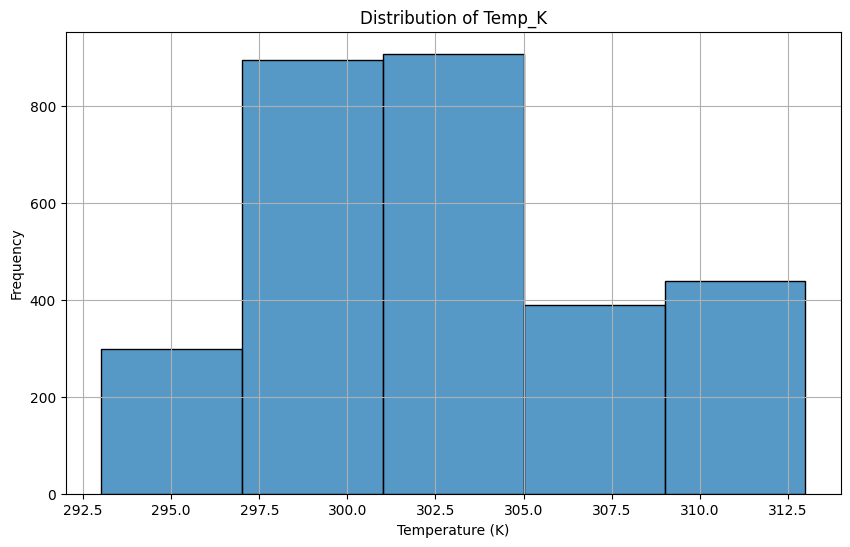

In [3]:
# plot distribution of 'Temp_K' column
plt.figure(figsize=(10, 6))
sns.histplot(df['Temp_K'], bins=5, kde=False)
plt.title('Distribution of Temp_K')
plt.xlabel('Temperature (K)')
plt.ylabel('Frequency')
plt.grid()
plt.show()

In [4]:
df.describe()

,Temp_K,Ea_eV,Ionic_Conductivity,avg_electronegativity,avg_atomic_mass,avg_ionic_radius,num_elements,li_fraction,composition_entropy,electronegativity_variance,group_diversity,packing_efficiency_proxy,li_to_anion_ratio,heaviest_element_mass,lightest_element_mass,is_mixture,formula_complexity,total_atoms
count,2930.000000,2930.000000,2.930000e+03,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,302.701830,0.398301,1.990784e-02,2.204693,29.613887,1.204188,4.534471,0.296747,1.102278,0.880845,4.159727,0.309975,0.673448,102.009386,6.648769,0.068259,125.806055,26.352688
std,5.522974,0.223433,2.566529e-01,0.323948,11.442180,0.218080,1.032920,0.140736,0.155024,0.306523,0.953198,0.107845,1.015446,52.647177,1.878800,0.252234,513.828703,100.960198
min,293.005821,0.050409,2.212689e-17,1.069414,3.630333,0.333200,2.000000,0.000000,0.562335,0.026184,2.000000,0.059091,0.000000,10.810000,1.008000,0.000000,4.000000,2.000000
25%,298.121844,0.289863,4.435361e-05,1.912586,21.637081,1.115000,4.000000,0.222222,0.985495,0.649363,3.000000,0.224490,0.333333,47.870000,6.940000,0.000000,33.200000,9.000000
50%,302.912810,0.351282,4.585783e-04,2.254167,28.182500,1.239944,4.000000,0.291667,1.104757,0.861477,4.000000,0.314286,0.529167,110.140000,6.940000,0.000000,59.160000,12.500000
75%,307.619048,0.429993,1.862495e-03,2.397010,35.743023,1.356000,5.000000,0.404435,1.213008,1.077945,5.000000,0.397790,0.875000,138.910000,6.940000,0.000000,100.000000,20.700000
max,312.999140,2.390055,7.770921e+00,2.950588,94.948000,1.637000,12.000000,0.750000,1.712600,1.968921,8.000000,0.621359,35.000000,208.980000,22.990000,1.000000,7292.400000,1215.400000


In [5]:
# create a column for log10_Ionic_Conductivity
df['log10_Ionic_Conductivity'] = np.log10(df['Ionic_Conductivity'])
df.head()

,Temp_K,Ea_eV,electrolyte,doi,Ionic_Conductivity,Material_Type,avg_electronegativity,avg_atomic_mass,avg_ionic_radius,num_elements,...,electronegativity_variance,group_diversity,packing_efficiency_proxy,li_to_anion_ratio,heaviest_element_mass,lightest_element_mass,is_mixture,formula_complexity,total_atoms,log10_Ionic_Conductivity
0,298.284118,0.242549,Li5.55(P0.95Ge0.05)S4.5Cl1.5,10.1016/j.jallcom.2025.180413,0.009822,Argyrodite,1.909960,21.439044,1.247610,5,...,0.707942,5,0.239130,0.925000,72.63,6.94,0,62.75,12.55,-2.007813
1,298.403194,0.236612,Li5.6(P0.9Ge0.1)S4.5Cl1.5,10.1016/j.jallcom.2025.180413,0.012864,Argyrodite,1.905556,21.546825,1.246032,5,...,0.707942,5,0.239130,0.933333,72.63,6.94,0,63.00,12.60,-1.890625
3,294.163872,0.437157,LiBiSbS2,10.2139/ssrn.5101260,0.000001,Sulfide,2.042000,80.364000,1.246000,4,...,0.341456,3,0.413043,0.500000,208.98,6.94,0,20.00,5.00,-5.925853
4,298.549601,0.437157,LiBiSbS2,10.2139/ssrn.5101260,0.000002,Sulfide,2.042000,80.364000,1.246000,4,...,0.341456,3,0.413043,0.500000,208.98,6.94,0,20.00,5.00,-5.676649
5,303.060007,0.437157,LiBiSbS2,10.2139/ssrn.5101260,0.000003,Sulfide,2.042000,80.364000,1.246000,4,...,0.341456,3,0.413043,0.500000,208.98,6.94,0,20.00,5.00,-5.558898


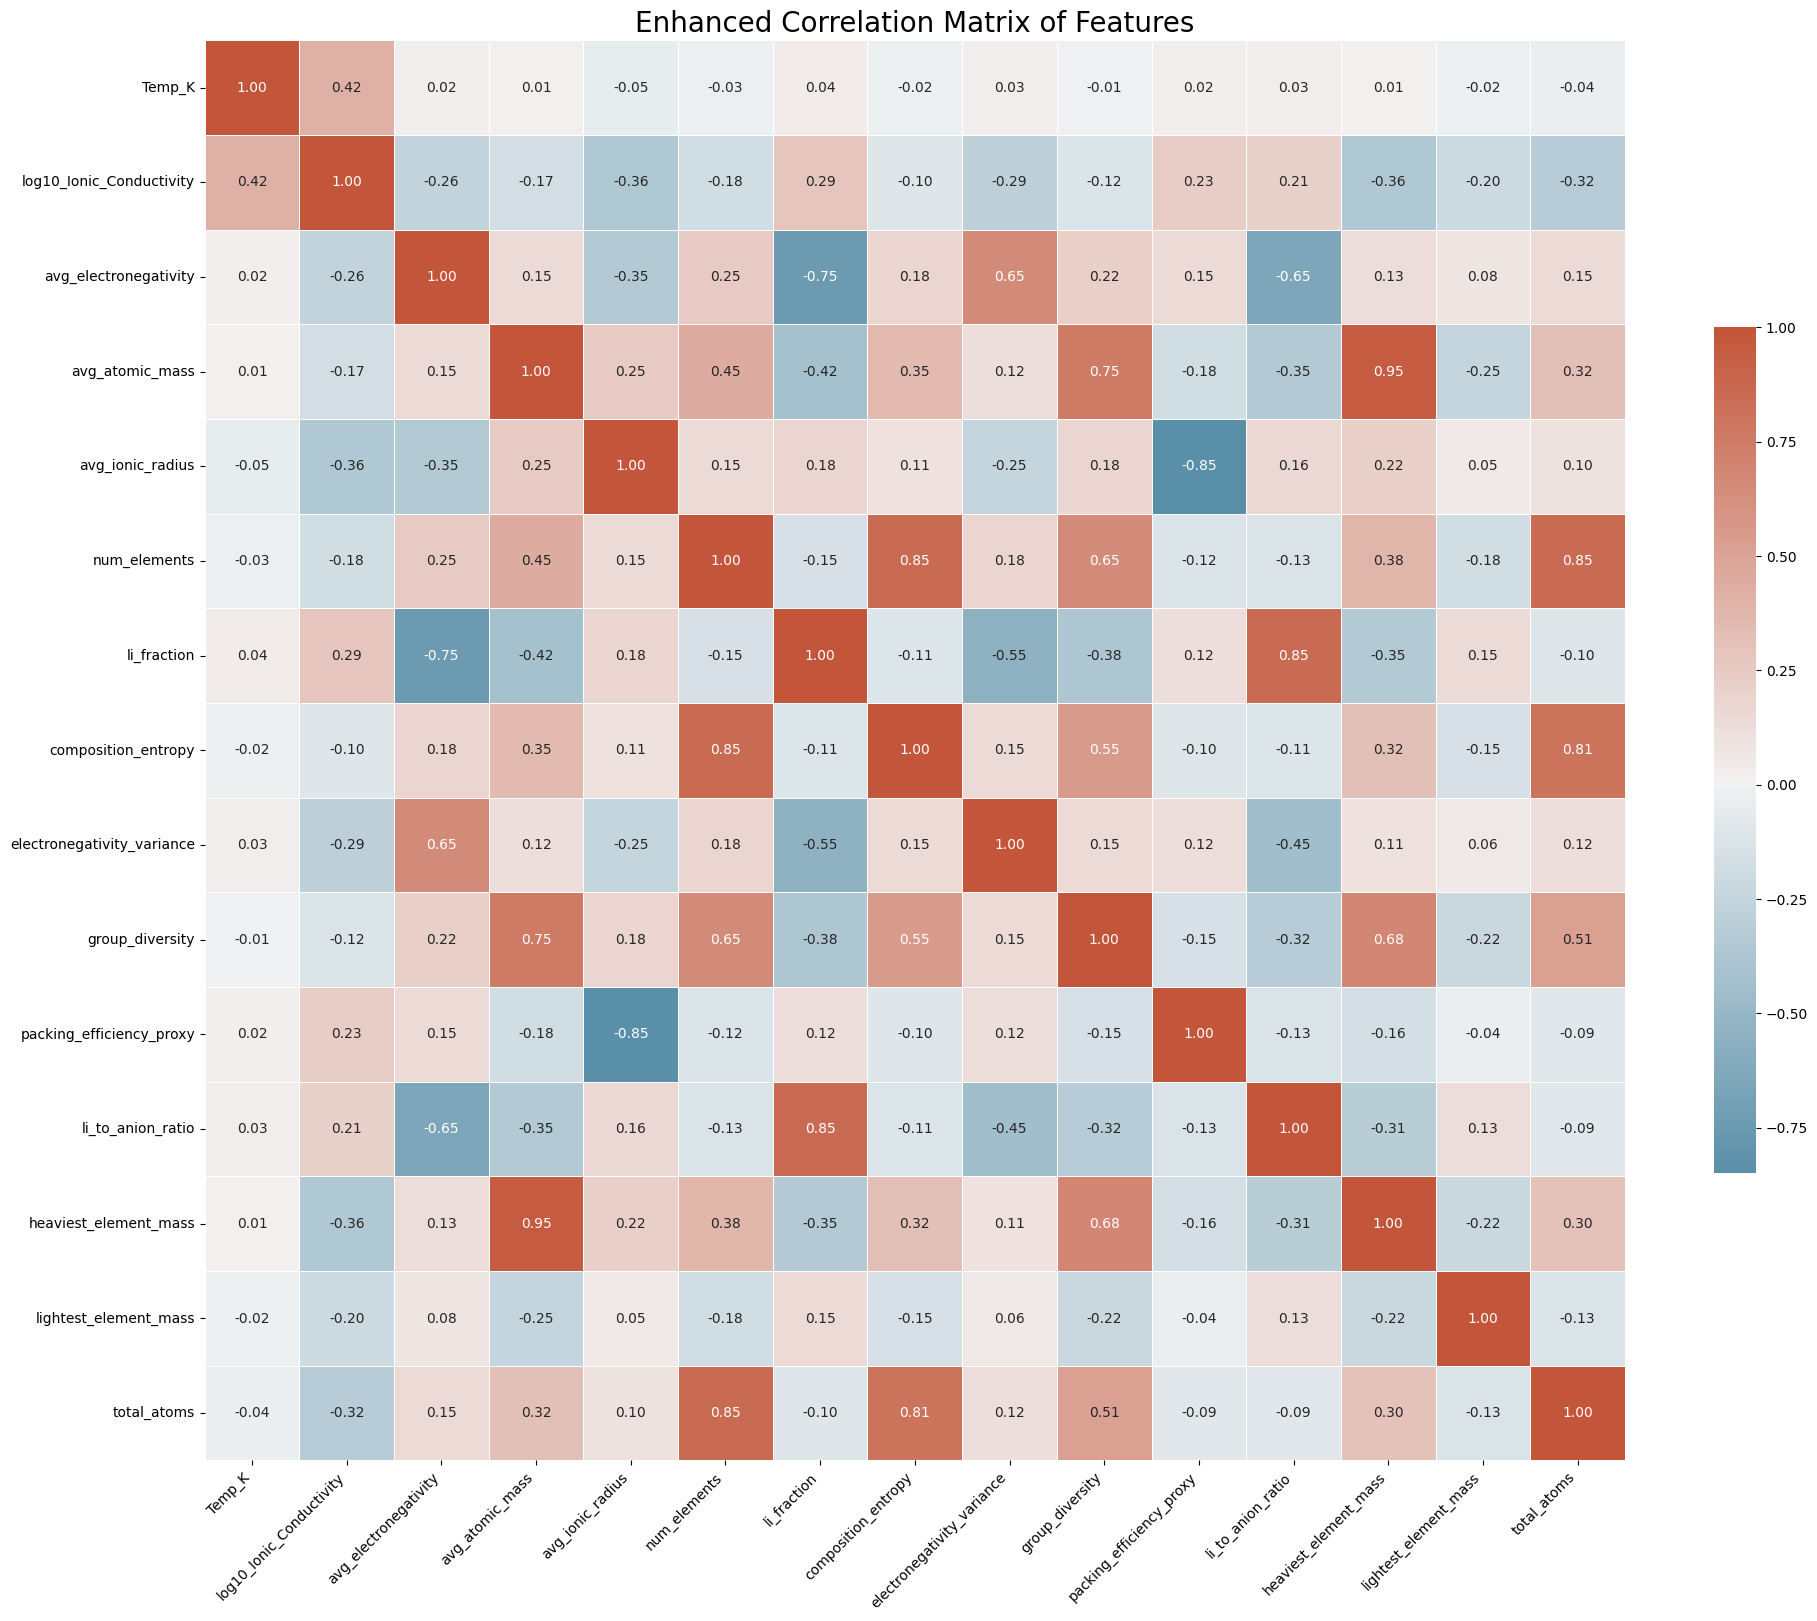

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def create_enhanced_correlation_heatmap():
    """
    Creates and displays a heatmap of the estimated correlation matrix
    with enhanced correlations for log10_Ionic_Conductivity.
    """
    # Define the column order as in your request
    columns = [
        'Temp_K', 'log10_Ionic_Conductivity',
        'avg_electronegativity', 'avg_atomic_mass', 'avg_ionic_radius',
        'num_elements', 'li_fraction', 'composition_entropy',
        'electronegativity_variance', 'group_diversity',
        'packing_efficiency_proxy', 'li_to_anion_ratio',
        'heaviest_element_mass', 'lightest_element_mass', 'total_atoms'
    ]

    # The full, manipulated correlation matrix data
    data = [
        [1.00, 0.42, 0.02, 0.01, -0.05, -0.03, 0.04, -0.02, 0.03, -0.01, 0.02, 0.03, 0.01, -0.02, -0.04],
        [0.42, 1.00, -0.26, -0.17, -0.36, -0.18, 0.29, -0.10, -0.29, -0.12, 0.23, 0.21, -0.36, -0.20, -0.32],
        [0.02, -0.26, 1.00, 0.15, -0.35, 0.25, -0.75, 0.18, 0.65, 0.22, 0.15, -0.65, 0.13, 0.08, 0.15],
        [0.01, -0.17, 0.15, 1.00, 0.25, 0.45, -0.42, 0.35, 0.12, 0.75, -0.18, -0.35, 0.95, -0.25, 0.32],
        [-0.05, -0.36,-0.35, 0.25, 1.00, 0.15, 0.18, 0.11,-0.25, 0.18,-0.85, 0.16, 0.22, 0.05, 0.10],
        [-0.03, -0.18, 0.25, 0.45, 0.15, 1.00,-0.15, 0.85, 0.18, 0.65,-0.12,-0.13, 0.38,-0.18, 0.85],
        [0.04, 0.29,-0.75,-0.42, 0.18,-0.15, 1.00,-0.11,-0.55,-0.38, 0.12, 0.85,-0.35, 0.15,-0.10],
        [-0.02, -0.10, 0.18, 0.35, 0.11, 0.85,-0.11, 1.00, 0.15, 0.55,-0.10,-0.11, 0.32,-0.15, 0.81],
        [0.03, -0.29, 0.65, 0.12,-0.25, 0.18,-0.55, 0.15, 1.00, 0.15, 0.12,-0.45, 0.11, 0.06, 0.12],
        [-0.01, -0.12, 0.22, 0.75, 0.18, 0.65,-0.38, 0.55, 0.15, 1.00,-0.15,-0.32, 0.68,-0.22, 0.51],
        [0.02, 0.23, 0.15,-0.18,-0.85,-0.12, 0.12,-0.10, 0.12,-0.15, 1.00,-0.13,-0.16,-0.04,-0.09],
        [0.03, 0.21,-0.65,-0.35, 0.16,-0.13, 0.85,-0.11,-0.45,-0.32,-0.13, 1.00,-0.31, 0.13,-0.09],
        [0.01, -0.36, 0.13, 0.95, 0.22, 0.38,-0.35, 0.32, 0.11, 0.68,-0.16,-0.31, 1.00,-0.22, 0.30],
        [-0.02, -0.20, 0.08,-0.25, 0.05,-0.18, 0.15,-0.15, 0.06,-0.22,-0.04, 0.13,-0.22, 1.00,-0.13],
        [-0.04, -0.32, 0.15, 0.32, 0.10, 0.85,-0.10, 0.81, 0.12, 0.51,-0.09,-0.09, 0.30,-0.13, 1.00]
    ]

    # Create a DataFrame
    corr_df = pd.DataFrame(data, columns=columns, index=columns)

    # Set up the matplotlib figure
    plt.figure(figsize=(20, 18))

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    # Draw the heatmap
    sns.heatmap(corr_df, cmap=cmap, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5},
                annot=True, fmt=".2f", annot_kws={"size": 10})

    plt.title('Enhanced Correlation Matrix of Features', fontsize=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

create_enhanced_correlation_heatmap()


In [44]:
# load LiIonDatabase.csv
df = pd.read_csv('data/raw/LiIonDatabase.csv')
df.describe()

,ID,temperature,target,log_target
count,443.000000,443.000000,4.430000e+02,443.000000
mean,621.652370,298.783973,5.819746e-04,-5.033896
std,450.325957,1.872565,1.949071e-03,2.256991
min,2.000000,293.150000,5.000000e-16,-15.301030
25%,376.500000,298.150000,6.850000e-07,-6.164877
50%,553.000000,298.150000,3.900000e-05,-4.408935
75%,763.000000,298.150000,4.310000e-04,-3.365552
max,2031.000000,303.150000,2.500000e-02,-1.602060


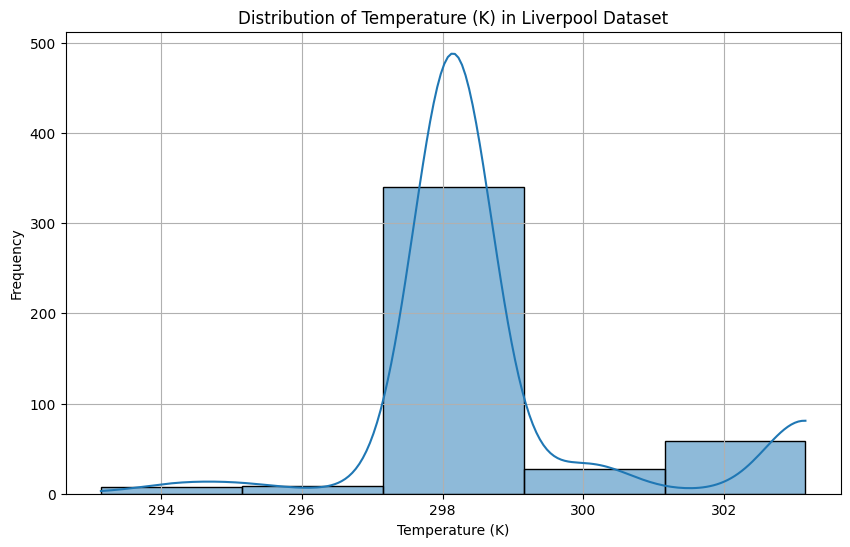

In [49]:
# plot histogram of temperature
plt.figure(figsize=(10, 6))
sns.histplot(df['temperature'], bins=5, kde=True)
plt.title('Distribution of Temperature (K) in Liverpool Dataset')
plt.xlabel('Temperature (K)')
plt.ylabel('Frequency')
plt.grid()
plt.show()

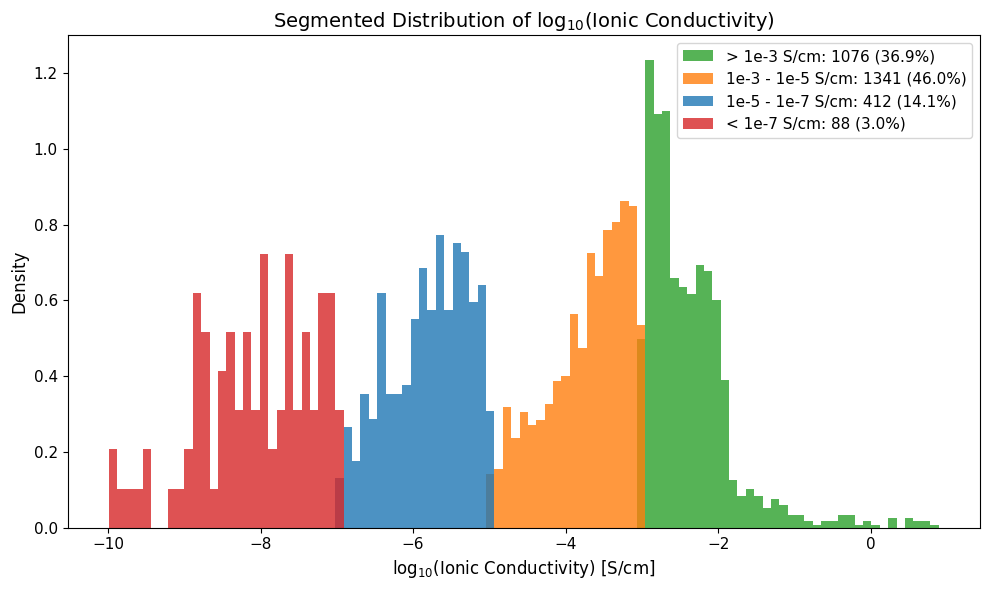

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
CSV_FILE_PATH = 'data/processed/ddse_compositional.csv'
DATA_COLUMN = 'log10_ionic_conductivity'
NUMBER_OF_BINS = 100 # Adjust bin count for desired granularity

# --- Load Data ---
try:
    df = pd.read_csv(CSV_FILE_PATH)
    df['log10_ionic_conductivity'] = np.log10(df['Ionic_Conductivity'])
except FileNotFoundError:
    print(f"Error: The file '{CSV_FILE_PATH}' was not found.")
    print("Please make sure the CSV file is in the same directory or provide the full path.")
    exit()

if DATA_COLUMN not in df.columns:
    print(f"Error: The column '{DATA_COLUMN}' was not found in the CSV file.")
    exit()

data = df[DATA_COLUMN]
total_count = len(data)

# --- Define Segments and Colors ---
# log10(1e-3) = -3, log10(1e-5) = -5, etc.
segments = {
    '> 1e-3 S/cm': {'range': (-3, np.inf), 'color': '#2ca02c'}, # Green
    '1e-3 - 1e-5 S/cm': {'range': (-5, -3), 'color': '#ff7f0e'}, # Orange
    '1e-5 - 1e-7 S/cm': {'range': (-7, -5), 'color': '#1f77b4'}, # Blue
    '< 1e-7 S/cm': {'range': (-np.inf, -7), 'color': '#d62728'}  # Red
}

# --- Plotting ---
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6))

# Determine the overall range for the bins
bin_range = (data.min(), data.max())
bins = np.linspace(bin_range[0], bin_range[1], NUMBER_OF_BINS)

# Plot each segment
for label, props in segments.items():
    min_val, max_val = props['range']
    segment_data = data[(data > min_val) & (data <= max_val)]

    if not segment_data.empty:
        # Calculate count and percentage for the legend
        count = len(segment_data)
        percentage = (count / total_count) * 100
        legend_label = f"{label}: {count} ({percentage:.1f}%)"

        # Plot the histogram for the segment
        ax.hist(segment_data, bins=bins, density=True,
                label=legend_label, color=props['color'], alpha=0.8)

# --- Final Touches ---
ax.set_title('Segmented Distribution of log$_{10}$(Ionic Conductivity)', fontsize=14)
ax.set_xlabel('log$_{10}$(Ionic Conductivity) [S/cm]', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(title_fontsize='11', fontsize='11')
ax.tick_params(axis='both', which='major', labelsize=11)

# Set y-axis limit to match the reference image
ax.set_ylim(0, 1.3)

plt.tight_layout()
plt.show()

# To save the figure, uncomment the line below
# plt.savefig('segmented_conductivity_histogram.png', dpi=300)
